**PRODUCT OPTIMZATION AND REVENUE CONTRIBUTION ANALYSIS**

In [1]:
#importing and installing frameworks and adding the data set

In [2]:

pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#importing frameworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import openpyxl



In [4]:
#importing dataset
url = "https://docs.google.com/spreadsheets/d/14CqwUgV3M37tz0ymk_utin29aDAKtdJA/export?format=xlsx"
df=pd.read_excel(url)
df.to_csv('Afficionado Coffee Roasters.csv', index=False)
print(df.head())
print(df.shape)

   transaction_id  year transaction_time  transaction_qty  store_id  \
0               1  2025         07:06:11                2         5   
1               2  2025         07:08:56                2         5   
2               3  2025         07:14:04                2         5   
3               4  2025         07:20:24                1         5   
4               5  2025         07:22:41                2         5   

    store_location  product_id  unit_price    product_category  \
0  Lower Manhattan          32         3.0              Coffee   
1  Lower Manhattan          57         3.1                 Tea   
2  Lower Manhattan          59         4.5  Drinking Chocolate   
3  Lower Manhattan          22         2.0              Coffee   
4  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                  Ethiopia Rg  
1        Brewed Chai tea     Spicy Eye Opener Chai Lg  
2       

**PHASE 1:- DATA EXPLORATION AND VALIDATION**



In [5]:
#CHECK SHAPE AND COLUMNS
df.shape
print(df.columns.tolist())
#check data types
df.dtypes
#checking missing values
df.isnull().sum()
#basic statistics
df.describe()

['transaction_id', 'year', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']


,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [6]:
#checking have zeros and negative values
chk=df.select_dtypes(include='number').columns
for col in chk:
    bad=df[df[col]<=0]
    print(f"{col}: {len(bad)} zeros/negative")






transaction_id: 0 zeros/negative
year: 0 zeros/negative
transaction_qty: 0 zeros/negative
store_id: 0 zeros/negative
product_id: 0 zeros/negative
unit_price: 0 zeros/negative


In [7]:
#creating a row that as revenue for calculating revenue
df['revenue']=df['transaction_qty'] * df['unit_price']

In [8]:
print(df.head(5))


   transaction_id  year transaction_time  transaction_qty  store_id  \
0               1  2025         07:06:11                2         5   
1               2  2025         07:08:56                2         5   
2               3  2025         07:14:04                2         5   
3               4  2025         07:20:24                1         5   
4               5  2025         07:22:41                2         5   

    store_location  product_id  unit_price    product_category  \
0  Lower Manhattan          32         3.0              Coffee   
1  Lower Manhattan          57         3.1                 Tea   
2  Lower Manhattan          59         4.5  Drinking Chocolate   
3  Lower Manhattan          22         2.0              Coffee   
4  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  revenue  
0  Gourmet brewed coffee                  Ethiopia Rg      6.0  
1        Brewed Chai tea     Spicy Eye Opener 

In [9]:
#checking how much product havein this data set
print(df['product_category'].unique())


<StringArray>
[            'Coffee',                'Tea', 'Drinking Chocolate',
             'Bakery',           'Flavours',          'Loose Tea',
       'Coffee beans', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str


In [10]:
#checking product popularity

popularity=df.groupby('product_detail')['transaction_qty'].sum().reset_index()
popularity

,product_detail,transaction_qty
0,Almond Croissant,1911
1,Brazilian - Organic,214
2,Brazilian Lg,4317
3,Brazilian Rg,4385
4,Brazilian Sm,4310
...,...,...
75,Sustainably Grown Organic Lg,4453
76,Sustainably Grown Organic Rg,4329
77,Traditional Blend Chai,153
78,Traditional Blend Chai Lg,4174


In [11]:
#finding highly popular product
popularity=popularity.sort_values('transaction_qty',ascending=False)
popularity.reset_index(drop=True)


,product_detail,transaction_qty
0,Earl Grey Rg,4708
1,Dark chocolate Lg,4668
2,Morning Sunrise Chai Rg,4643
3,Latte,4602
4,Peppermint Rg,4564
...,...,...
75,Jamacian Coffee River,146
76,Earl Grey,142
77,Guatemalan Sustainably Grown,134
78,Spicy Eye Opener Chai,122


In [12]:
#Revenue contribution analylsis

revenue_by_product=df.groupby('product_detail')['revenue'].sum().reset_index()
revenue_by_product

,product_detail,revenue
0,Almond Croissant,7168.13
1,Brazilian - Organic,3852.00
2,Brazilian Lg,15109.50
3,Brazilian Rg,13155.00
4,Brazilian Sm,9482.00
...,...,...
75,Sustainably Grown Organic Lg,21151.75
76,Sustainably Grown Organic Rg,16233.75
77,Traditional Blend Chai,1369.35
78,Traditional Blend Chai Lg,12522.00


In [13]:
#sort it into highest to lowest

revenue_by_product=revenue_by_product.sort_values('revenue',ascending=False)
revenue_by_product=revenue_by_product.reset_index(drop=True)
revenue_by_product

,product_detail,revenue
0,Sustainably Grown Organic Lg,21151.75
1,Dark chocolate Lg,21006.00
2,Latte Rg,19112.25
3,Cappuccino Lg,17641.75
4,Morning Sunrise Chai Lg,17384.00
...,...,...
75,Lemon Grass,1360.40
76,Guatemalan Sustainably Grown,1340.00
77,Spicy Eye Opener Chai,1335.90
78,Earl Grey,1270.90


In [14]:
revenue_by_product['revenue share %']= (revenue_by_product['revenue']/revenue_by_product['revenue'].sum())*100
revenue_by_product

,product_detail,revenue,revenue share %
0,Sustainably Grown Organic Lg,21151.75,3.026814
1,Dark chocolate Lg,21006.00,3.005957
2,Latte Rg,19112.25,2.734962
3,Cappuccino Lg,17641.75,2.524533
4,Morning Sunrise Chai Lg,17384.00,2.487649
...,...,...,...
75,Lemon Grass,1360.40,0.194673
76,Guatemalan Sustainably Grown,1340.00,0.191754
77,Spicy Eye Opener Chai,1335.90,0.191167
78,Earl Grey,1270.90,0.181866


In [15]:
#catogery and product type analysis 

#find which category dominates revenue
category_revenue=df.groupby('product_category')['revenue'].sum().reset_index()
category_revenue=category_revenue.sort_values('revenue',ascending=False).reset_index(drop=True)
category_revenue['revenue share %']= (category_revenue['revenue']/category_revenue['revenue'].sum())*100
category_revenue


,product_category,revenue,revenue share %
0,Coffee,269952.45,38.630178
1,Tea,196405.95,28.105679
2,Bakery,82315.64,11.779363
3,Drinking Chocolate,72416.00,10.362725
4,Coffee beans,40085.25,5.736197
5,Branded,13607.00,1.947161
6,Loose Tea,11213.60,1.604665
7,Flavours,8408.80,1.203299
8,Packaged Chocolate,4407.64,0.630733


In [16]:
type_revenue=df.groupby(['product_category','product_type'])['revenue'].sum().reset_index()
type_revenue=type_revenue.sort_values('revenue',ascending=False).reset_index(drop=True)
type_revenue['revenue share %']=(type_revenue['revenue']/type_revenue['revenue'].sum())*100
type_revenue

,product_category,product_type,revenue,revenue share %
0,Coffee,Barista Espresso,91406.20,13.080221
1,Tea,Brewed Chai tea,77081.95,11.030422
2,Drinking Chocolate,Hot chocolate,72416.00,10.362725
3,Coffee,Gourmet brewed coffee,70034.60,10.021947
4,Tea,Brewed Black tea,47932.00,6.859066
5,Tea,Brewed herbal tea,47539.50,6.802899
6,Coffee,Premium brewed coffee,38781.15,5.549580
7,Coffee,Organic brewed coffee,37746.50,5.401522
8,Bakery,Scone,36866.12,5.275539
9,Coffee,Drip coffee,31984.00,4.576908


In [17]:
#Pareto analysis
#find how many product drive 80% total revenue
revenue_by_product['cumulative_revenue_share%']=(revenue_by_product['revenue'].cumsum()/revenue_by_product['revenue'].sum())*100
pareto_80=revenue_by_product[revenue_by_product['cumulative_revenue_share%']<=80]
print(f"Products driving 80% revenue: {len(pareto_80)} out of {len(revenue_by_product)}")

revenue_by_product


Products driving 80% revenue: 42 out of 80


,product_detail,revenue,revenue share %,cumulative_revenue_share%
0,Sustainably Grown Organic Lg,21151.75,3.026814,3.026814
1,Dark chocolate Lg,21006.00,3.005957,6.032771
2,Latte Rg,19112.25,2.734962,8.767733
3,Cappuccino Lg,17641.75,2.524533,11.292266
4,Morning Sunrise Chai Lg,17384.00,2.487649,13.779916
...,...,...,...,...
75,Lemon Grass,1360.40,0.194673,99.327144
76,Guatemalan Sustainably Grown,1340.00,0.191754,99.518898
77,Spicy Eye Opener Chai,1335.90,0.191167,99.710065
78,Earl Grey,1270.90,0.181866,99.891931


In [18]:
#Popularity VS revenue scatter

#compare each product unit sold vs revenue to find heroes, gems and dead weight 
product_matrix=pd.merge(popularity,revenue_by_product, on='product_detail')
product_matrix=product_matrix[['product_detail','transaction_qty','revenue']]
rev_median=product_matrix['revenue'].median()
qty_median=product_matrix['transaction_qty'].median()
print(qty_median)



3629.5


In [19]:
#finding heroes gems and dead weight

product_matrix['Quadrant']='Dead Weight'

product_matrix.loc[(product_matrix['transaction_qty']> qty_median) &(product_matrix['revenue']>rev_median),'Quadrant']='Hero product'
product_matrix.loc[(product_matrix['transaction_qty']< qty_median )& (product_matrix['revenue']>rev_median),'Quadrant']='Hidden Gem product'
product_matrix.loc[(product_matrix['transaction_qty']> qty_median )&(product_matrix['revenue']<rev_median),'Quadrant']=' high vol low rev product'
product_matrix.loc[(product_matrix['transaction_qty']< qty_median )&(product_matrix['revenue']<rev_median),'Quadrant']=' Dead Weight'
product_matrix

,product_detail,transaction_qty,revenue,Quadrant
0,Earl Grey Rg,4708,11770.0,Hero product
1,Dark chocolate Lg,4668,21006.0,Hero product
2,Morning Sunrise Chai Rg,4643,11607.5,Hero product
3,Latte,4602,17257.5,Hero product
4,Peppermint Rg,4564,11410.0,Hero product
...,...,...,...,...
75,Jamacian Coffee River,146,2883.5,Dead Weight
76,Earl Grey,142,1270.9,Dead Weight
77,Guatemalan Sustainably Grown,134,1340.0,Dead Weight
78,Spicy Eye Opener Chai,122,1335.9,Dead Weight


***VISUALISATION***


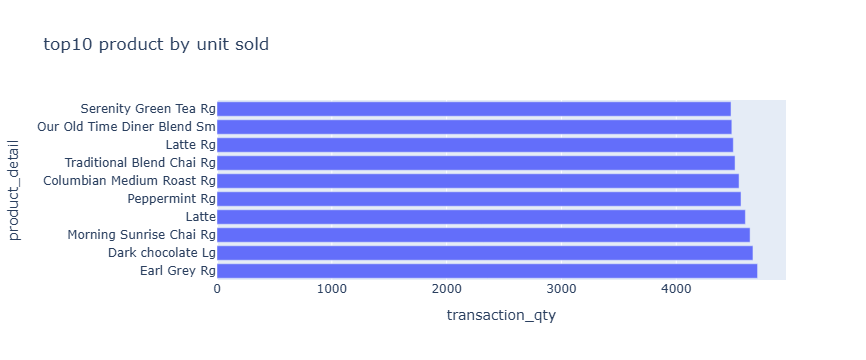

In [20]:
#CHART 1
#top 10 product by unit sold

popularity=popularity.reset_index(drop=True)
top10=popularity.head(10)
fig1=px.bar(top10,
          x='transaction_qty',
          y='product_detail',
          orientation='h',
          title='top10 product by unit sold')
fig1




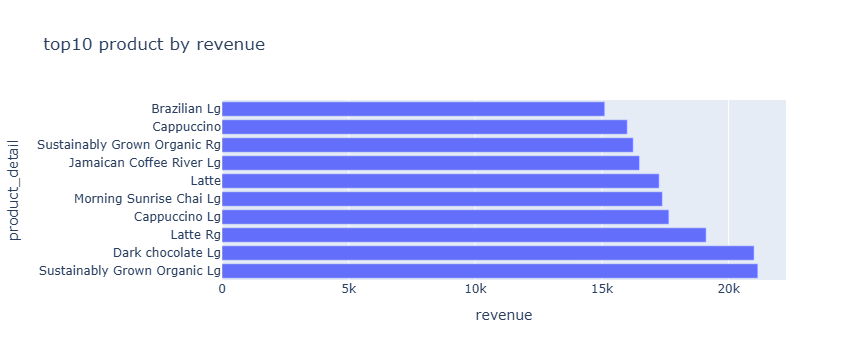

In [21]:
#chart 2 
#top 10 product by revenue
top10_rev=revenue_by_product.head(10)
fig2=px.bar(top10_rev,
           x='revenue',
           y='product_detail',
            orientation='h',
            title='top10 product by revenue'
)
fig2

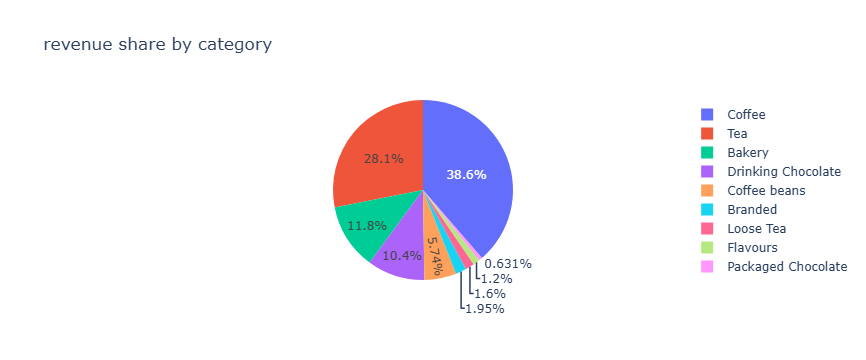

In [22]:
#CHART 3
#revenue share by category (pie chart)


fig3=px.pie(category_revenue,
      names='product_category',
      values='revenue',
      title='revenue share by category ')
fig3

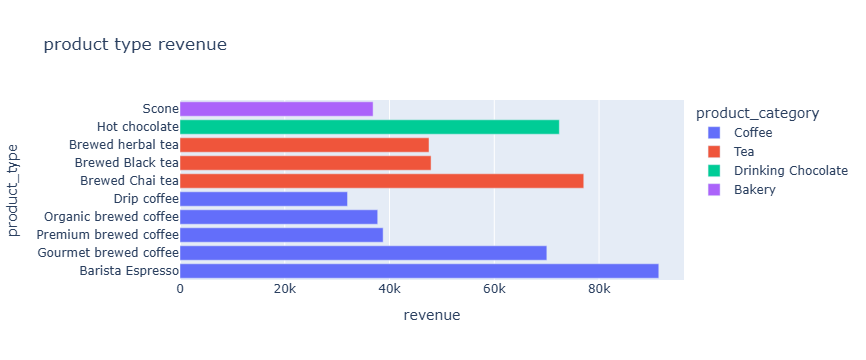

In [23]:
#CHART 4
#-product type revenue
fig4=px.bar(type_revenue.head(10),
           x='revenue',
           y='product_type',
           color='product_category',
           orientation='h',
           title='product type revenue')
fig4

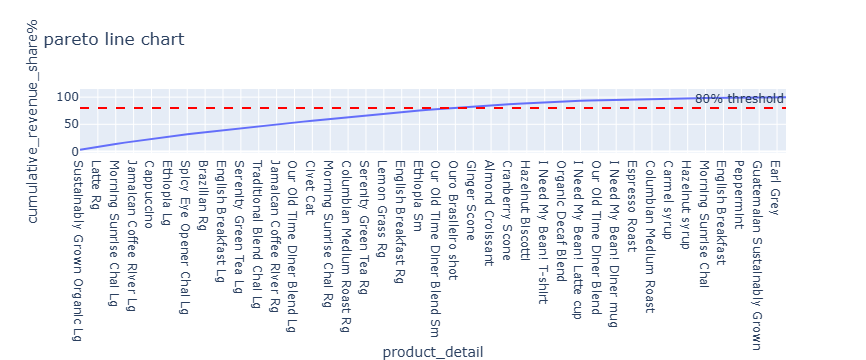

In [24]:
#CHART 5
#pareto line chart

fig5=px.line(revenue_by_product.sort_values('cumulative_revenue_share%'),
            x='product_detail',
            y='cumulative_revenue_share%',
            title='pareto line chart')
fig5.add_hline(y=80,line_dash='dash',line_color='red',annotation_text='80% threshold')

fig5

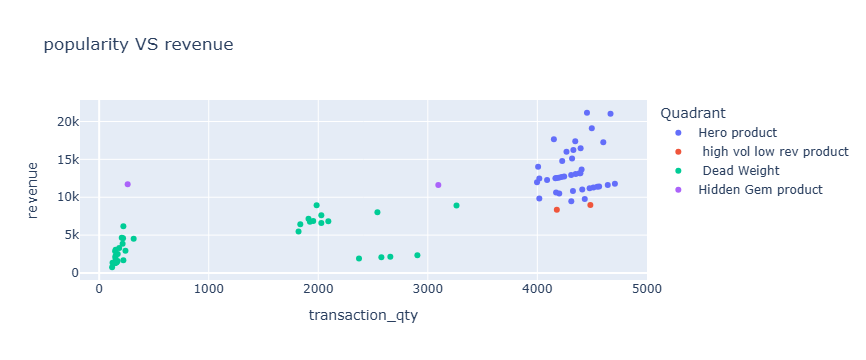

In [25]:
#CHART 6
#scatter plot (popularity vs revenue)

fig6=px.scatter(product_matrix,
               x='transaction_qty',
               y='revenue',
               color='Quadrant',
               hover_name='product_detail',
               title='popularity VS revenue')

fig6
